<a href="https://colab.research.google.com/github/Ashour36/ML-projects/blob/main/polished_predict_aqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Predicting Air Quality Index (AQI)
This notebook demonstrates how to build, evaluate, and save a machine learning model to predict AQI (Air Quality Index) based on available features. It is structured for clarity and ready for handoff to developers.


## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Set seed for reproducibility
np.random.seed(42)

## Load and Explore Data

In [ ]:
from io import StringIO

from google.colab import files
uploaded = files.upload()   # choose urban_environmental_data.csv

# 🔹 Step 2: Get the filename automatically
filename = list(uploaded.keys())[0]

# 🔹 Step 3: Read file safely, clean weird backticks if they exist
with open(filename, "r", encoding="utf-8") as f:
    lines = f.readlines()

# Remove backticks or unwanted characters
cleaned = [line.replace("```", "").strip() for line in lines]

# Reload cleaned data into pandas
df = pd.read_csv(StringIO("\n".join(cleaned)), sep=",", engine="python")

# 🔹 Step 4: Auto-clean column names
df.columns = (
    df.columns
    .str.replace(r"[()\[\]/%²]", "", regex=True)  # remove special chars
    .str.replace(" ", "_")                        # spaces → underscores
    .str.strip()
)

print("✅ Columns after cleaning:")
print(df.columns.tolist())

# Preview dataset
df.head()



Saving urban_environmental_data.csv to urban_environmental_data (17).csv
✅ Columns after cleaning:
['Year', 'Country', 'City', 'SurfaceTemperature°C', 'AirQualityIndexAQI', 'CO2_Emissionsµgm³', 'PM2.5µgm³', 'PopulationMillions', 'PopulationDensitypeoplekm', 'GreenArea', 'WaterResourcesm³_per_capita', 'WasteGeneratedtonsyear', 'RenewableEnergy', 'UrbanGrowthRate']


,Year,Country,City,SurfaceTemperature°C,AirQualityIndexAQI,CO2_Emissionsµgm³,PM2.5µgm³,PopulationMillions,PopulationDensitypeoplekm,GreenArea,WaterResourcesm³_per_capita,WasteGeneratedtonsyear,RenewableEnergy,UrbanGrowthRate
0,2015,USA,New York,13.2,52,757.6,9.9,8.40,11000,34.9,7988,5040000,10.8,1.1
1,2016,USA,New York,12.8,48,751.7,10.3,8.44,11055,35.0,7824,5065200,10.1,0.9
2,2017,USA,New York,12.5,45,750.9,9.9,8.48,11110,35.5,7829,5090525,12.0,0.9
3,2018,USA,New York,12.8,42,763.9,9.5,8.53,11165,34.4,7747,5115978,12.7,1.2
4,2019,USA,New York,13.1,48,759.9,8.1,8.57,11221,34.7,7586,5141558,13.3,1.0


##  Exploratory Data Analysis (EDA)

In [ ]:
# Check for missing values
df.isna().sum()

,0
Year,0
Country,0
City,0
SurfaceTemperature°C,0
AirQualityIndexAQI,0
CO2_Emissionsµgm³,0
PM2.5µgm³,0
PopulationMillions,0
PopulationDensitypeoplekm,0
GreenArea,0


In [ ]:
# Basic statistics
df.describe()

,Year,SurfaceTemperature°C,AirQualityIndexAQI,CO2_Emissionsµgm³,PM2.5µgm³,PopulationMillions,PopulationDensitypeoplekm,GreenArea,WaterResourcesm³_per_capita,WasteGeneratedtonsyear,RenewableEnergy,UrbanGrowthRate
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.00000,2.500000e+02,250.000000,250.00000
mean,2019.500000,23.417600,98.036000,789.825600,27.143200,6.708200,7554.320000,18.476000,2712.10000,2.846225e+06,17.018000,2.00840
std,2.878043,4.538847,35.616469,24.965106,10.979172,6.337511,6072.627838,7.958884,3215.05646,2.568423e+06,13.989248,0.60835
min,2015.000000,10.900000,36.000000,724.600000,6.400000,0.400000,1500.000000,8.600000,15.00000,2.000000e+05,2.000000,0.80000
25%,2017.000000,20.900000,65.000000,772.250000,18.725000,1.585000,3280.000000,12.650000,217.25000,6.321825e+05,8.200000,1.60000
50%,2019.500000,23.500000,103.500000,791.200000,30.550000,4.000000,4879.500000,16.250000,260.00000,1.964014e+06,11.550000,2.20000
75%,2022.000000,27.200000,123.000000,806.300000,35.100000,8.740000,10288.250000,21.275000,5460.00000,3.928256e+06,16.500000,2.47500
max,2024.000000,30.000000,170.000000,845.200000,46.600000,24.380000,25091.000000,40.400000,8995.00000,1.004979e+07,48.400000,3.00000


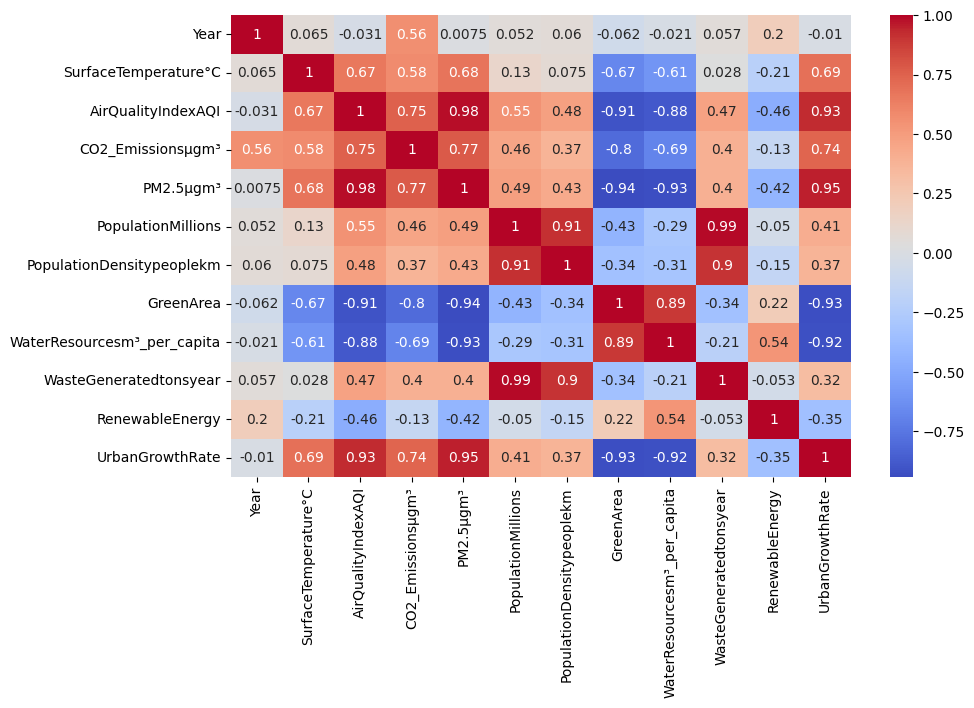

In [ ]:
# Select numeric columns automatically
numeric_df = df.select_dtypes(include=['number'])

# Check if we have numeric columns
if numeric_df.shape[1] > 0:
    plt.figure(figsize=(10,6))
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
    plt.show()
else:
    print("⚠️ No numeric columns found for correlation heatmap.")


##  Preprocessing and Train/Test Split

In [ ]:
print(df.columns)


Index(['Year', 'Country', 'City', 'SurfaceTemperature°C', 'AirQualityIndexAQI',
       'CO2_Emissionsµgm³', 'PM2.5µgm³', 'PopulationMillions',
       'PopulationDensitypeoplekm', 'GreenArea', 'WaterResourcesm³_per_capita',
       'WasteGeneratedtonsyear', 'RenewableEnergy', 'UrbanGrowthRate'],
      dtype='object')


In [ ]:
X = df.drop(columns=['AirQualityIndexAQI', 'Country', 'City'])
y = df['AirQualityIndexAQI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##  Model Training with Pipeline

In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestRegressor(random_state=42))])

##  Model Evaluation

In [ ]:
y_pred = pipe.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.2f}')
print(f'R²: {r2:.2f}')

MSE: 21.79
R²: 0.98


##  Save Final Model

In [ ]:
joblib.dump(pipe, 'final_model.pkl')
print('Model saved as final_model.pkl')

Model saved as final_model.pkl


##  Example Prediction on New Data

In [ ]:
X_new = [X.iloc[0].values]  # using first row as example

loaded_model = joblib.load('final_model.pkl')
prediction = loaded_model.predict(X_new)
print('Prediction for X_new:', prediction)

Prediction for X_new: [49.73]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


 ## Export Dependencies

In [ ]:
!pip freeze > requirements.txt
print('requirements.txt generated')

requirements.txt generated
